In [ ]:
!git clone https://github.com/MgSO4-7H2O/AI_safety_lab.git

Cloning into 'AI_safety_lab'...
remote: Enumerating objects: 71832, done.
remote: Counting objects: 100% (71832/71832), done.
remote: Compressing objects: 100% (12773/12773), done.
remote: Total 71832 (delta 59058), reused 71832 (delta 59058), pack-reused 0 (from 0)
Receiving objects: 100% (71832/71832), 31.13 MiB | 19.06 MiB/s, done.
Resolving deltas: 100% (59058/59058), done.
Updating files: 100% (72710/72710), done.


In [ ]:
%cd AI_safety_lab/lab2/adv_cv
!ls


/content/AI_safety_lab/lab2/adv_cv
code.ipynb  mnist  mnist_cnn.pt  mnist_mobile.pt


In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


2.11.0+cu128
True
Tesla T4


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from PIL import Image
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)

        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = F.relu(x)

        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)

        x = self.fc2(x)

        output = F.log_softmax(x, dim=1)
        return output


class MobileNet(nn.Module):
    def __init__(self):
        super(MobileNet, self).__init__()

        self.mobilenet = models.mobilenet_v3_small(weights=None)
        self.mobilenet.classifier = nn.Sequential(
            nn.Linear(576, 10)
        )

    def forward(self, x):
        x = self.mobilenet(x)
        output = F.log_softmax(x, dim=1)
        return output


print("Models defined.")

Models defined.


In [ ]:
def test(model, device, test_loader, name="model"):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            test_loss += F.nll_loss(output, target, reduction="sum").item()

            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    print(f"{name}")
    print(f"Average loss: {test_loss:.4f}")
    print(f"Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)")
    print()

    return accuracy

In [ ]:
test_transform = transforms.Compose([
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(
    root="mnist/testing",
    transform=test_transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=100,
    shuffle=False,
    num_workers=0
)

print("Test dataset size:", len(test_dataset))
print("Classes:", test_dataset.classes)

Test dataset size: 10000
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [ ]:
cnn = Net().to(device)
cnn.load_state_dict(torch.load("mnist_cnn.pt", map_location=device))
cnn.eval()

mobile = MobileNet().to(device)
mobile.load_state_dict(torch.load("mnist_mobile.pt", map_location=device))
mobile.eval()

print("CNN and MobileNet loaded.")

RuntimeError: Error(s) in loading state_dict for MobileNet:
	Missing key(s) in state_dict: "mobilenet.features.0.0.weight", "mobilenet.features.0.1.weight", "mobilenet.features.0.1.bias", "mobilenet.features.0.1.running_mean", "mobilenet.features.0.1.running_var", "mobilenet.features.1.block.0.0.weight", "mobilenet.features.1.block.0.1.weight", "mobilenet.features.1.block.0.1.bias", "mobilenet.features.1.block.0.1.running_mean", "mobilenet.features.1.block.0.1.running_var", "mobilenet.features.1.block.1.fc1.weight", "mobilenet.features.1.block.1.fc1.bias", "mobilenet.features.1.block.1.fc2.weight", "mobilenet.features.1.block.1.fc2.bias", "mobilenet.features.1.block.2.0.weight", "mobilenet.features.1.block.2.1.weight", "mobilenet.features.1.block.2.1.bias", "mobilenet.features.1.block.2.1.running_mean", "mobilenet.features.1.block.2.1.running_var", "mobilenet.features.2.block.0.0.weight", "mobilenet.features.2.block.0.1.weight", "mobilenet.features.2.block.0.1.bias", "mobilenet.feature

In [ ]:
class MobileNet(nn.Module):
    def __init__(self):
        super(MobileNet, self).__init__()

        base_model = models.mobilenet_v3_small(weights=None)

        self.trunk = nn.Sequential(
            base_model.features,
            base_model.avgpool,
            nn.Flatten(),
            nn.Linear(576, 10)
        )

    def forward(self, x):
        x = self.trunk(x)
        output = F.log_softmax(x, dim=1)
        return output


print("MobileNet redefined with trunk structure.")

MobileNet redefined with trunk structure.


In [ ]:
cnn = Net().to(device)
cnn.load_state_dict(torch.load("mnist_cnn.pt", map_location=device))
cnn.eval()

mobile = MobileNet().to(device)
mobile.load_state_dict(torch.load("mnist_mobile.pt", map_location=device))
mobile.eval()

print("CNN and MobileNet loaded.")

CNN and MobileNet loaded.


In [ ]:
class MobileNet(nn.Module):
    def __init__(self):
        super(MobileNet, self).__init__()

        base_model = models.mobilenet_v3_small(weights=None)

        self.trunk = nn.Sequential(
            base_model.features,
            base_model.avgpool,
            nn.Flatten()
        )

        self.fc = nn.Sequential(
            nn.Linear(576, 10)
        )

    def forward(self, x):
        x = self.trunk(x)
        x = self.fc(x)
        output = F.log_softmax(x, dim=1)
        return output


print("MobileNet redefined with trunk + fc structure.")

MobileNet redefined with trunk + fc structure.


In [ ]:
cnn_clean_acc = test(cnn, device, test_loader, name="CNN on clean MNIST")
mobile_clean_acc = test(mobile, device, test_loader, name="MobileNet on clean MNIST")

CNN on clean MNIST
Average loss: 0.2690
Accuracy: 9831/10000 (98.31%)

MobileNet on clean MNIST
Average loss: 3.6020
Accuracy: 1138/10000 (11.38%)



In [ ]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307, 0.1307, 0.1307),
        (0.3081, 0.3081, 0.3081)
    )
])

test_dataset = datasets.ImageFolder(
    root="mnist/testing",
    transform=test_transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=100,
    shuffle=False,
    num_workers=0
)

print("Test dataset size:", len(test_dataset))
print("Classes:", test_dataset.classes)

Test dataset size: 10000
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [ ]:
cnn_clean_acc = test(cnn, device, test_loader, name="CNN on clean MNIST")
mobile_clean_acc = test(mobile, device, test_loader, name="MobileNet on clean MNIST")

CNN on clean MNIST
Average loss: 0.0477
Accuracy: 9828/10000 (98.28%)

MobileNet on clean MNIST
Average loss: 0.0703
Accuracy: 9772/10000 (97.72%)



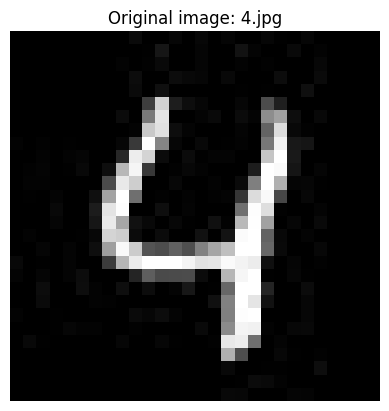

CNN prediction for original 4.jpg: 4


In [ ]:
single_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

four_img = Image.open("mnist/pic/4.jpg").convert("RGB")
four_tensor = single_transform(four_img).unsqueeze(0).to(device)

plt.imshow(four_tensor[0].detach().cpu().permute(1, 2, 0))
plt.title("Original image: 4.jpg")
plt.axis("off")
plt.show()

with torch.no_grad():
    output = cnn(four_tensor)
    pred = output.argmax(dim=1).item()

print("CNN prediction for original 4.jpg:", pred)

In [ ]:
def l_infinity_pgd(
    model,
    tensor,
    gt,
    epsilon=40/255,
    target=None,
    iteration=100,
    lr=0.01,
    show=True
):
    model.eval()

    tensor = tensor.to(device)
    delta = torch.zeros_like(tensor, requires_grad=True, device=device)
    optimizer = optim.SGD([delta], lr=lr)

    gt_tensor = torch.LongTensor([gt]).to(device)

    if target is not None:
        target_tensor = torch.LongTensor([target]).to(device)

    for i in range(iteration):
        adv_tensor = torch.clamp(tensor + delta, 0, 1)
        pred = model(adv_tensor)

        if target is None:
            # 无目标攻击：让模型远离真实标签
            loss = -F.nll_loss(pred, gt_tensor)
        else:
            # 有目标攻击：让模型预测成 target
            loss = F.nll_loss(pred, target_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        delta.data.clamp_(-epsilon, epsilon)
        delta.data = torch.clamp(tensor + delta.data, 0, 1) - tensor

    adv_tensor = torch.clamp(tensor + delta, 0, 1).detach()

    with torch.no_grad():
        adv_output = model(adv_tensor)
        adv_pred = adv_output.argmax(dim=1).item()

    if show:
        plt.figure(figsize=(10, 3))

        plt.subplot(1, 3, 1)
        plt.imshow(tensor[0].detach().cpu().permute(1, 2, 0))
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        perturbation = delta[0].detach().cpu().permute(1, 2, 0)
        plt.imshow((perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8))
        plt.title("Perturbation")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(adv_tensor[0].detach().cpu().permute(1, 2, 0))
        plt.title(f"Adversarial pred: {adv_pred}")
        plt.axis("off")

        plt.show()

    return adv_tensor, adv_pred

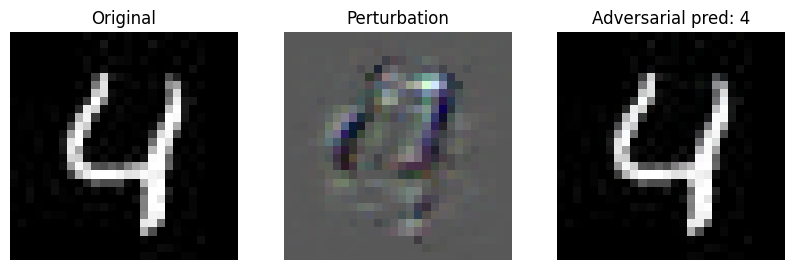

Untargeted attack prediction: 4


In [ ]:
adv_four_untargeted, pred_untargeted = l_infinity_pgd(
    model=cnn,
    tensor=four_tensor,
    gt=4,
    epsilon=40/255,
    target=None,
    iteration=100,
    lr=0.01,
    show=True
)

print("Untargeted attack prediction:", pred_untargeted)

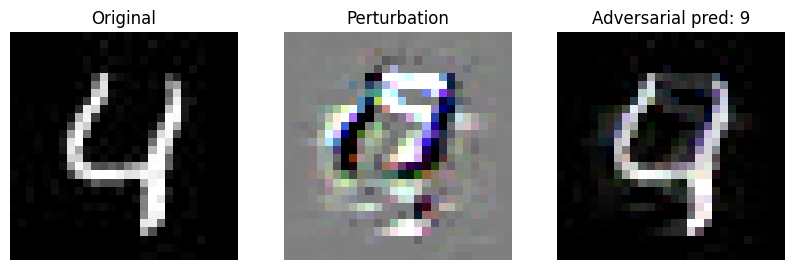

Untargeted attack prediction: 9


In [ ]:
adv_four_untargeted, pred_untargeted = l_infinity_pgd(
    model=cnn,
    tensor=four_tensor,
    gt=4,
    epsilon=40/255,
    target=None,
    iteration=1000,
    lr=0.01,
    show=True
)

print("Untargeted attack prediction:", pred_untargeted)

In [ ]:
def pgd_untargeted(
    model,
    tensor,
    gt,
    epsilon=40/255,
    alpha=2/255,
    iteration=100,
    show=True
):
    model.eval()

    x = tensor.clone().detach().to(device)
    y = torch.LongTensor([gt]).to(device)

    delta = torch.zeros_like(x).to(device)

    for i in range(iteration):
        delta.requires_grad = True

        adv_x = torch.clamp(x + delta, 0, 1)
        output = model(adv_x)

        # 无目标攻击：最大化真实类别的分类损失
        loss = F.nll_loss(output, y)

        model.zero_grad()
        if delta.grad is not None:
            delta.grad.zero_()

        loss.backward()

        # PGD: 沿着梯度符号方向增加 loss
        grad = delta.grad.detach()
        delta = delta + alpha * grad.sign()

        # 投影回 L∞ epsilon 范围
        delta = torch.clamp(delta, -epsilon, epsilon)

        # 保证图像像素仍在 [0, 1]
        delta = torch.clamp(x + delta, 0, 1) - x
        delta = delta.detach()

    adv_x = torch.clamp(x + delta, 0, 1).detach()

    with torch.no_grad():
        adv_output = model(adv_x)
        adv_pred = adv_output.argmax(dim=1).item()

    if show:
        plt.figure(figsize=(10, 3))

        plt.subplot(1, 3, 1)
        plt.imshow(x[0].detach().cpu().permute(1, 2, 0))
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        perturbation = delta[0].detach().cpu().permute(1, 2, 0)
        plt.imshow((perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8))
        plt.title("Perturbation")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(adv_x[0].detach().cpu().permute(1, 2, 0))
        plt.title(f"Adversarial pred: {adv_pred}")
        plt.axis("off")

        plt.show()

    return adv_x, adv_pred

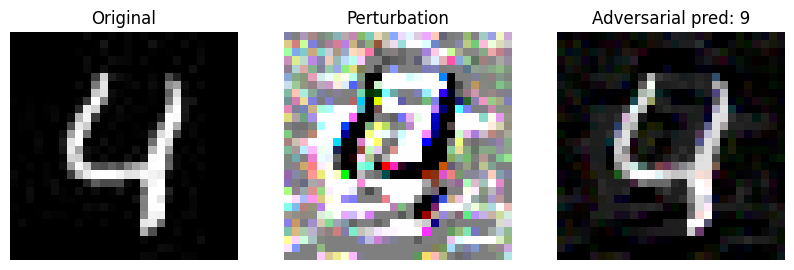

Untargeted attack prediction: 9


In [ ]:
adv_four_untargeted, pred_untargeted = pgd_untargeted(
    model=cnn,
    tensor=four_tensor,
    gt=4,
    epsilon=40/255,
    alpha=2/255,
    iteration=15,
    show=True
)

print("Untargeted attack prediction:", pred_untargeted)

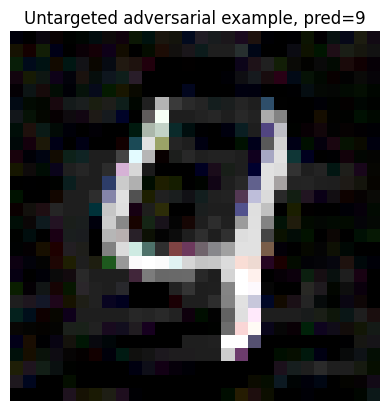

Saved to results/adv_four_untargeted.png


In [ ]:
os.makedirs("results", exist_ok=True)

save_img = adv_four_untargeted[0].detach().cpu().permute(1, 2, 0).numpy()

plt.imshow(save_img)
plt.title(f"Untargeted adversarial example, pred={pred_untargeted}")
plt.axis("off")
plt.savefig("results/adv_four_untargeted.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved to results/adv_four_untargeted.png")

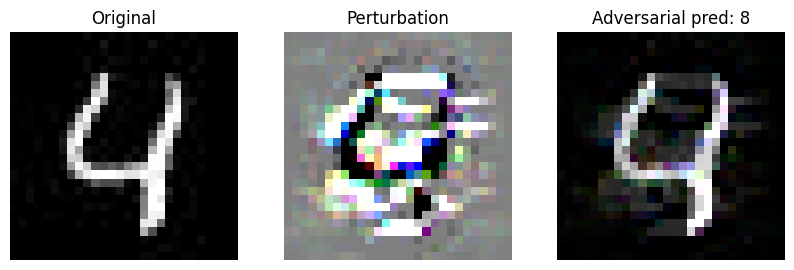

Targeted attack target: 8
Targeted attack prediction: 8


In [ ]:
adv_four_targeted, pred_targeted = l_infinity_pgd(
    model=cnn,
    tensor=four_tensor,
    gt=4,
    epsilon=40/255,
    target=8,
    iteration=1400,
    lr=0.01,
    show=True
)

print("Targeted attack target: 8")
print("Targeted attack prediction:", pred_targeted)

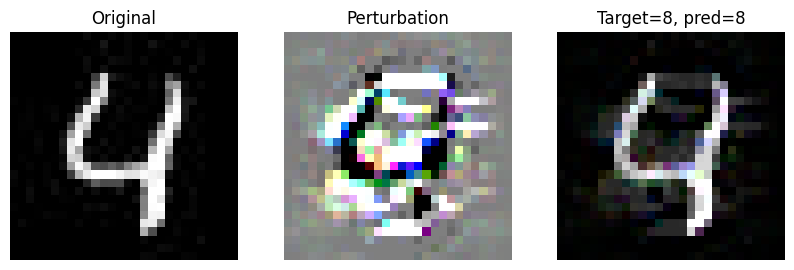

Saved to results/pgd_targeted_4_to_8.png


In [ ]:
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.imshow(four_tensor[0].detach().cpu().permute(1, 2, 0))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
perturbation = (adv_four_targeted - four_tensor)[0].detach().cpu().permute(1, 2, 0)
plt.imshow((perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8))
plt.title("Perturbation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(adv_four_targeted[0].detach().cpu().permute(1, 2, 0))
plt.title(f"Target=8, pred={pred_targeted}")
plt.axis("off")

plt.savefig("results/pgd_targeted_4_to_8.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved to results/pgd_targeted_4_to_8.png")

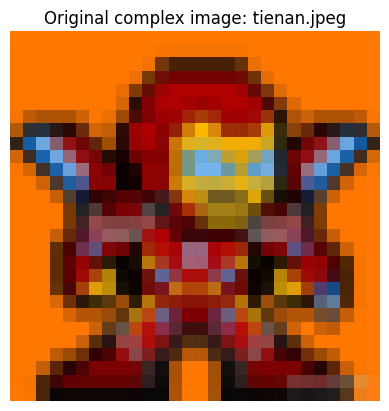

CNN prediction for original tienan.jpeg: 7


In [ ]:
complex_img = Image.open("mnist/pic/tienan.jpeg").convert("RGB")
complex_tensor = single_transform(complex_img).unsqueeze(0).to(device)

plt.imshow(complex_tensor[0].detach().cpu().permute(1, 2, 0))
plt.title("Original complex image: tienan.jpeg")
plt.axis("off")
plt.show()

with torch.no_grad():
    output = cnn(complex_tensor)
    complex_pred = output.argmax(dim=1).item()

print("CNN prediction for original tienan.jpeg:", complex_pred)

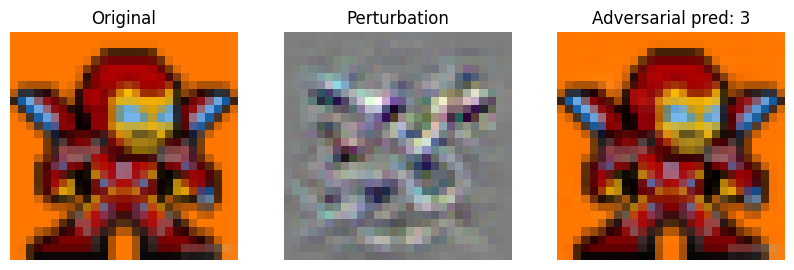

Targeted attack target: 3
Prediction after attack: 3


In [ ]:
adv_complex, pred_complex_adv = l_infinity_pgd(
    model=cnn,
    tensor=complex_tensor,
    gt=complex_pred,
    epsilon=60/255,
    target=3,
    iteration=200,
    lr=0.01,
    show=True
)

print("Targeted attack target: 3")
print("Prediction after attack:", pred_complex_adv)

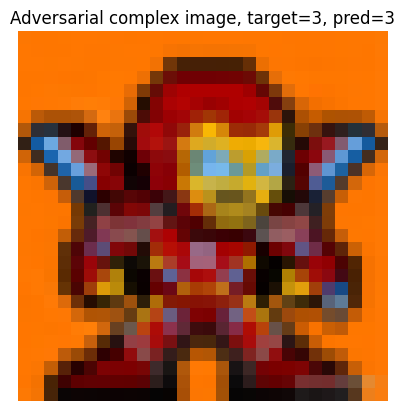

Saved to results/adv_tienan_target_3.png


In [ ]:
save_img = adv_complex[0].detach().cpu().permute(1, 2, 0).numpy()

plt.imshow(save_img)
plt.title(f"Adversarial complex image, target=3, pred={pred_complex_adv}")
plt.axis("off")
plt.savefig("results/adv_tienan_target_3.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved to results/adv_tienan_target_3.png")

In [ ]:
from torchvision.utils import save_image
from torchvision import datasets, transforms
import os
import torch
import torch.nn.functional as F

# 与前面测试集保持一致的 MNIST 三通道归一化参数
mean = torch.tensor([0.1307, 0.1307, 0.1307]).view(1, 3, 1, 1).to(device)
std = torch.tensor([0.3081, 0.3081, 0.3081]).view(1, 3, 1, 1).to(device)

def normalize_batch(x):
    return (x - mean) / std


def pgd_untargeted_for_transfer(
    model,
    tensor,
    gt,
    epsilon=40/255,
    alpha=2/255,
    iteration=50
):
    """
    用 CNN 生成无目标 PGD 对抗样本。
    作用：让模型不再预测原始类别 gt。

    注意：
    - 扰动约束在原始像素空间 [0,1] 中进行；
    - 输入模型前使用 Normalize，保持和测试阶段一致；
    - 保存图片时保存的是 [0,1] 范围内的可视图像。
    """

    model.eval()

    x = tensor.clone().detach().to(device)
    y = torch.LongTensor([gt]).to(device)

    delta = torch.zeros_like(x).to(device)

    for i in range(iteration):
        delta.requires_grad = True

        adv_x = torch.clamp(x + delta, 0, 1)
        output = model(normalize_batch(adv_x))

        # 无目标攻击：最大化真实类别 gt 的 loss
        loss = F.nll_loss(output, y)

        model.zero_grad()
        if delta.grad is not None:
            delta.grad.zero_()

        loss.backward()

        grad = delta.grad.detach()

        # PGD sign-gradient 更新
        delta = delta + alpha * grad.sign()

        # 投影回 L∞ epsilon 范围
        delta = torch.clamp(delta, -epsilon, epsilon)

        # 保证图像像素范围仍在 [0,1]
        delta = torch.clamp(x + delta, 0, 1) - x
        delta = delta.detach()

    adv_x = torch.clamp(x + delta, 0, 1).detach()

    with torch.no_grad():
        clean_pred = model(normalize_batch(x)).argmax(dim=1).item()
        adv_pred = model(normalize_batch(adv_x)).argmax(dim=1).item()

    return adv_x, clean_pred, adv_pred


def create_transfer_adv_dataset(
    model,
    source_root="mnist/testing",
    save_root="mnist/adv_ori_label",
    samples_per_class=100,
    epsilon=40/255,
    alpha=2/255,
    iteration=50
):
    """
    批量生成用于迁移攻击实验的对抗样本数据集。

    保存结构：
    mnist/adv_ori_label/
        0/
        1/
        ...
        9/

    注意：
    每张对抗样本保存到它的原始真实标签文件夹中。
    例如原图真实类别是 4，即使攻击后 CNN 预测为 9，也保存到：
    mnist/adv_ori_label/4/
    """

    os.makedirs(save_root, exist_ok=True)

    for cls in range(10):
        os.makedirs(os.path.join(save_root, str(cls)), exist_ok=True)

    raw_transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor()
    ])

    dataset = datasets.ImageFolder(
        root=source_root,
        transform=raw_transform
    )

    class_count = {i: 0 for i in range(10)}
    total_saved = 0

    clean_correct = 0
    attack_success = 0

    for idx, (data, gt) in enumerate(dataset):
        if class_count[gt] >= samples_per_class:
            continue

        data = data.unsqueeze(0).to(device)

        adv_img, clean_pred, adv_pred = pgd_untargeted_for_transfer(
            model=model,
            tensor=data,
            gt=gt,
            epsilon=epsilon,
            alpha=alpha,
            iteration=iteration
        )

        if clean_pred == gt:
            clean_correct += 1

        if adv_pred != gt:
            attack_success += 1

        filename = (
            f"adv_ori_{gt}"
            f"_idx_{class_count[gt]}"
            f"_cleanpred_{clean_pred}"
            f"_advpred_{adv_pred}.png"
        )

        save_path = os.path.join(
            save_root,
            str(gt),
            filename
        )

        save_image(adv_img[0].detach().cpu(), save_path)

        class_count[gt] += 1
        total_saved += 1

        if total_saved % 50 == 0:
            print(
                f"Saved: {total_saved} | "
                f"Clean correct: {clean_correct}/{total_saved} ({100 * clean_correct / total_saved:.2f}%) | "
                f"Attack success: {attack_success}/{total_saved} ({100 * attack_success / total_saved:.2f}%)"
            )

        if all(class_count[c] >= samples_per_class for c in range(10)):
            break

    print("Done.")
    print("Total saved:", total_saved)
    print(f"Clean correct: {clean_correct}/{total_saved} ({100 * clean_correct / total_saved:.2f}%)")
    print(f"Attack success on source CNN: {attack_success}/{total_saved} ({100 * attack_success / total_saved:.2f}%)")
    print("Saved root:", save_root)

In [ ]:
create_transfer_adv_dataset(
    model=cnn,
    source_root="mnist/testing",
    save_root="mnist/adv_ori_label_test",
    samples_per_class=2,
    epsilon=40/255,
    alpha=2/255,
    iteration=100
)

Done.
Total saved: 20
Clean correct: 19/20 (95.00%)
Attack success on source CNN: 13/20 (65.00%)
Saved root: mnist/adv_ori_label_test


In [ ]:
create_transfer_adv_dataset(
    model=cnn,
    source_root="mnist/testing",
    save_root="mnist/adv_ori_label",
    samples_per_class=100,
    epsilon=40/255,
    alpha=2/255,
    iteration=100
)

Saved: 50 | Clean correct: 50/50 (100.00%) | Attack success: 14/50 (28.00%)
Saved: 100 | Clean correct: 100/100 (100.00%) | Attack success: 33/100 (33.00%)
Saved: 150 | Clean correct: 150/150 (100.00%) | Attack success: 56/150 (37.33%)
Saved: 200 | Clean correct: 198/200 (99.00%) | Attack success: 75/200 (37.50%)
Saved: 250 | Clean correct: 248/250 (99.20%) | Attack success: 103/250 (41.20%)
Saved: 300 | Clean correct: 297/300 (99.00%) | Attack success: 138/300 (46.00%)
Saved: 350 | Clean correct: 347/350 (99.14%) | Attack success: 172/350 (49.14%)
Saved: 400 | Clean correct: 394/400 (98.50%) | Attack success: 205/400 (51.25%)
Saved: 450 | Clean correct: 442/450 (98.22%) | Attack success: 247/450 (54.89%)
Saved: 500 | Clean correct: 491/500 (98.20%) | Attack success: 294/500 (58.80%)
Saved: 550 | Clean correct: 539/550 (98.00%) | Attack success: 330/550 (60.00%)
Saved: 600 | Clean correct: 589/600 (98.17%) | Attack success: 363/600 (60.50%)
Saved: 650 | Clean correct: 636/650 (97.85%) 

In [ ]:
adv_dataset = datasets.ImageFolder(
    root="mnist/adv_ori_label",
    transform=test_transform
)

adv_loader = torch.utils.data.DataLoader(
    adv_dataset,
    batch_size=100,
    shuffle=False,
    num_workers=0
)

print("Adversarial dataset size:", len(adv_dataset))
print("Classes:", adv_dataset.classes)

Adversarial dataset size: 1000
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [ ]:
cnn_adv_acc = test(
    cnn,
    device,
    adv_loader,
    name="CNN on adversarial dataset generated by CNN"
)

mobile_adv_acc = test(
    mobile,
    device,
    adv_loader,
    name="MobileNet on adversarial dataset generated by CNN"
)

CNN on adversarial dataset generated by CNN
Average loss: 2.3995
Accuracy: 348/1000 (34.80%)

MobileNet on adversarial dataset generated by CNN
Average loss: 1.7365
Accuracy: 503/1000 (50.30%)



In [ ]:
import pandas as pd
import os

os.makedirs("results", exist_ok=True)

transfer_result_table = pd.DataFrame({
    "Model": ["CNN", "MobileNet"],
    "Clean Accuracy (%)": [cnn_clean_acc, mobile_clean_acc],
    "Adversarial Accuracy (%)": [cnn_adv_acc, mobile_adv_acc],
    "Accuracy Drop (%)": [
        cnn_clean_acc - cnn_adv_acc,
        mobile_clean_acc - mobile_adv_acc
    ]
})

transfer_result_table.to_csv(
    "results/transfer_attack_results.csv",
    index=False
)

transfer_result_table

,Model,Clean Accuracy (%),Adversarial Accuracy (%),Accuracy Drop (%)
0,CNN,98.28,34.8,63.48
1,MobileNet,97.72,50.3,47.42


In [ ]:
from torchvision import transforms
import torch
import pandas as pd
import os

def denoise_tensor_batch(x):
    """
    对一个 batch 的图像做 GaussianBlur。
    输入 x 是已经 Normalize 后的 tensor。
    这里先反归一化回 [0,1]，模糊后再 Normalize。
    """
    blur = transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))

    mean_cpu = torch.tensor([0.1307, 0.1307, 0.1307]).view(1, 3, 1, 1)
    std_cpu = torch.tensor([0.3081, 0.3081, 0.3081]).view(1, 3, 1, 1)

    x_cpu = x.detach().cpu()

    # 反归一化回 [0,1]
    x_raw = x_cpu * std_cpu + mean_cpu
    x_raw = torch.clamp(x_raw, 0, 1)

    # 对每张图做高斯模糊
    x_blur = torch.stack([blur(img) for img in x_raw])

    # 再归一化，保持和模型输入一致
    x_blur_norm = (x_blur - mean_cpu) / std_cpu

    return x_blur_norm.to(device)


def test_with_denoise(model, device, test_loader, name="model with denoise"):
    """
    测试模型在经过 GaussianBlur 去噪后的数据集上的准确率。
    """
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)

            data = denoise_tensor_batch(data)

            output = model(data)
            test_loss += F.nll_loss(output, target, reduction="sum").item()

            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    print(f"{name}")
    print(f"Average loss: {test_loss:.4f}")
    print(f"Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)")
    print()

    return accuracy


print("Denoise test functions defined.")

Denoise test functions defined.


In [ ]:
cnn_adv_denoise_acc = test_with_denoise(
    cnn,
    device,
    adv_loader,
    name="CNN on adversarial dataset with GaussianBlur"
)

mobile_adv_denoise_acc = test_with_denoise(
    mobile,
    device,
    adv_loader,
    name="MobileNet on adversarial dataset with GaussianBlur"
)

CNN on adversarial dataset with GaussianBlur
Average loss: 1.7432
Accuracy: 470/1000 (47.00%)

MobileNet on adversarial dataset with GaussianBlur
Average loss: 2.2439
Accuracy: 404/1000 (40.40%)



In [ ]:
import pandas as pd
import os

os.makedirs("results", exist_ok=True)

summary_result_table = pd.DataFrame({
    "Model": ["CNN", "MobileNet"],
    "Clean Accuracy (%)": [cnn_clean_acc, mobile_clean_acc],
    "Adversarial Accuracy (%)": [cnn_adv_acc, mobile_adv_acc],
    "Accuracy Drop on Adversarial Samples (%)": [
        cnn_clean_acc - cnn_adv_acc,
        mobile_clean_acc - mobile_adv_acc
    ],
    "After GaussianBlur Accuracy (%)": [
        cnn_adv_denoise_acc,
        mobile_adv_denoise_acc
    ],
    "GaussianBlur Change (%)": [
        cnn_adv_denoise_acc - cnn_adv_acc,
        mobile_adv_denoise_acc - mobile_adv_acc
    ]
})

summary_result_table.to_csv(
    "results/final_summary_results.csv",
    index=False
)

summary_result_table

,Model,Clean Accuracy (%),Adversarial Accuracy (%),Accuracy Drop on Adversarial Samples (%),After GaussianBlur Accuracy (%),GaussianBlur Change (%)
0,CNN,98.28,34.8,63.48,47.0,12.2
1,MobileNet,97.72,50.3,47.42,40.4,-9.9


In [ ]:
defense_result_table = pd.DataFrame({
    "Model": ["CNN", "MobileNet"],
    "Adversarial Accuracy Before Denoise (%)": [
        cnn_adv_acc,
        mobile_adv_acc
    ],
    "Adversarial Accuracy After GaussianBlur (%)": [
        cnn_adv_denoise_acc,
        mobile_adv_denoise_acc
    ],
    "Accuracy Change After Denoise (%)": [
        cnn_adv_denoise_acc - cnn_adv_acc,
        mobile_adv_denoise_acc - mobile_adv_acc
    ]
})

defense_result_table.to_csv(
    "results/defense_gaussian_blur_results.csv",
    index=False
)

defense_result_table

,Model,Adversarial Accuracy Before Denoise (%),Adversarial Accuracy After GaussianBlur (%),Accuracy Change After Denoise (%)
0,CNN,34.8,47.0,12.2
1,MobileNet,50.3,40.4,-9.9


In [ ]:
!zip -r lab2_final_results.zip results mnist/adv_ori_label

  adding: results/ (stored 0%)
  adding: results/adv_four_untargeted.png (deflated 26%)
  adding: results/defense_gaussian_blur_results.csv (deflated 34%)
  adding: results/transfer_attack_results.csv (deflated 22%)
  adding: results/adv_tienan_target_3.png (deflated 25%)
  adding: results/pgd_targeted_4_to_8.png (deflated 22%)
  adding: results/final_summary_results.csv (deflated 39%)
  adding: mnist/adv_ori_label/ (stored 0%)
  adding: mnist/adv_ori_label/5/ (stored 0%)
  adding: mnist/adv_ori_label/5/adv_ori_5_idx_25_cleanpred_5_advpred_6.png (stored 0%)
  adding: mnist/adv_ori_label/5/adv_ori_5_idx_59_cleanpred_5_advpred_0.png (stored 0%)
  adding: mnist/adv_ori_label/5/adv_ori_5_idx_94_cleanpred_5_advpred_3.png (stored 0%)
  adding: mnist/adv_ori_label/5/adv_ori_5_idx_81_cleanpred_5_advpred_5.png (stored 0%)
  adding: mnist/adv_ori_label/5/adv_ori_5_idx_30_cleanpred_5_advpred_0.png (stored 0%)
  adding: mnist/adv_ori_label/5/adv_ori_5_idx_74_cleanpred_5_advpred_3.png (stored 0%)
 